##Task 1: Basis Functions and their Support

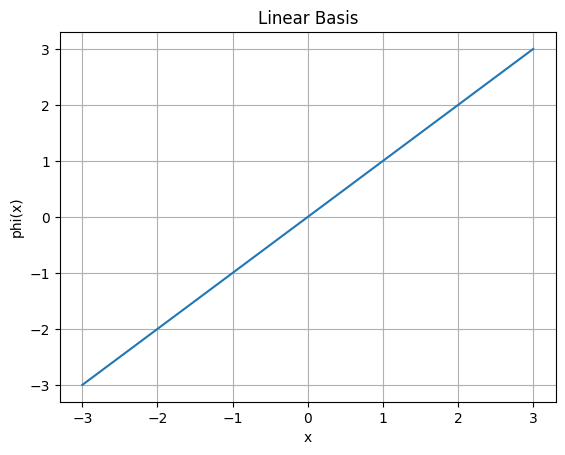

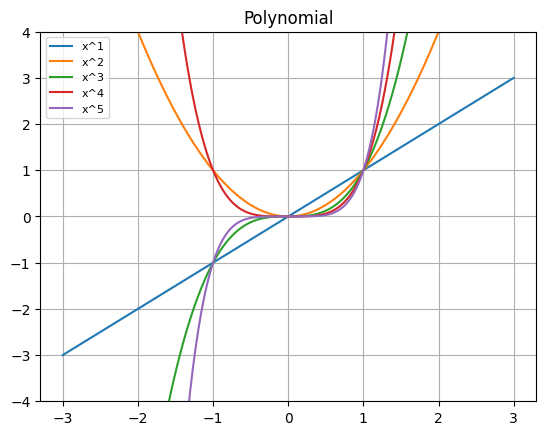

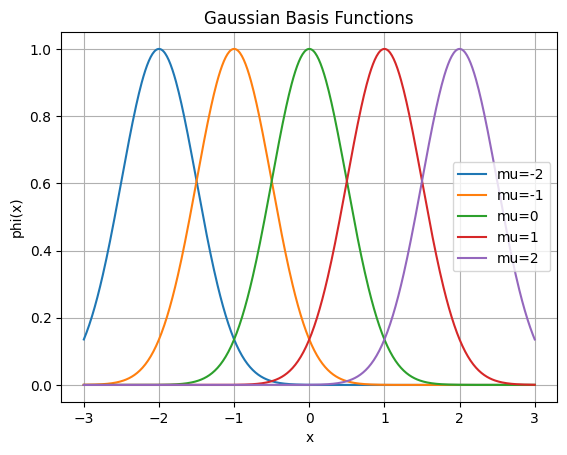

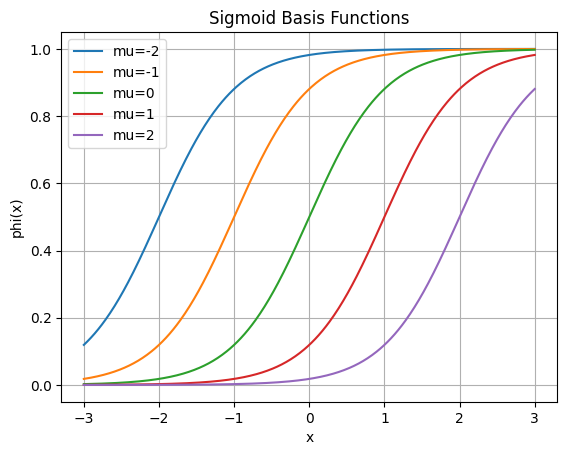

Polynomial
1 0.10000000000000003
2 0.07000000000000003
3 0.03700000000000002
4 0.017500000000000005
5 0.007810000000000003
Gaussian
-2 1.548984221034821e-05
-1 0.014206359990229032
0 0.10912117433758117
1 0.11144115710857211
2 0.0028873074867691658
Sigmoid
-2 0.001789230713744372
-1 0.011814244444477984
0 0.04431817490181711
1 0.033659105059564126
2 0.00687025809831384


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(-3, 3, 500)
phi_linear = x
plt.plot(x, phi_linear)
plt.xlabel("x")
plt.ylabel("phi(x)")
plt.title("Linear Basis")
plt.grid()
plt.show()
for k in range(1, 6):
    plt.plot(x, x**k, label=f'x^{k}')
plt.axis([plt.xlim()[0], plt.xlim()[1], -4, 4])
plt.title('Polynomial')
plt.legend(fontsize=8)
plt.grid()
plt.show()
mu_values = [-2, -1, 0, 1, 2]
s = 0.5
for mu in mu_values:
    phi = np.exp(-((x - mu) ** 2) / (2 * s ** 2))
    plt.plot(x, phi, label=f"mu={mu}")

plt.xlabel("x")
plt.ylabel("phi(x)")
plt.title("Gaussian Basis Functions")
plt.legend()
plt.grid()
plt.show()

mu_values = [-2, -1, 0, 1, 2]
s = 0.5

for mu in mu_values:
    phi = 1 / (1 + np.exp(-(x - mu) / s))
    plt.plot(x, phi, label=f"mu={mu}")

plt.xlabel("x")
plt.ylabel("phi(x)")
plt.title("Sigmoid Basis Functions")
plt.legend()
plt.grid()
plt.show()

x0 = 0.3
delta = 0.1
print('Polynomial')
for j in range(1, 6):
    phi1 = x0 ** j
    phi2 = (x0 + delta) ** j
    difference = abs(phi2 - phi1)

    print(j, difference)
print('Gaussian')
for mu in mu_values:
    phi1 = np.exp(-((x0 - mu) ** 2) / (2 * s ** 2))
    phi2 = np.exp(-(((x0 + delta) - mu) ** 2) / (2 * s ** 2))

    difference = abs(phi2 - phi1)

    print(mu, difference)
print('Sigmoid')
for mu in mu_values:
    phi1 = 1 / (1 + np.exp(-(x0 - mu) / s))
    phi2 = 1 / (1 + np.exp(-((x0 + delta) - mu) / s))

    difference = abs(phi2 - phi1)

    print(mu, difference)

The linear basis function shows a straight-line global behaviour over the complete input range. Polynomial basis functions also have global behaviour because their values vary over the entire input domain. Increasing the polynomial degree changes the shape more strongly away from the origin.

Gaussian basis functions show localized behaviour. Each Gaussian has its maximum value near its center mu, and its value decreases rapidly away from the center. Therefore, a Gaussian basis mainly affects a local region around its center.

Sigmoid basis functions show smooth transition behaviour. The parameter mu determines the location of the transition, while s controls the spread of the transition.

For x0=0.3 and delta=0.1, the calculated differences show how much each basis function changes for a small change in the input. Gaussian and sigmoid functions have larger changes when x0 lies near their active regions, while their changes are smaller when they are relatively flat at x0.

## Task 2: Polynomial Basis for a Smooth Global Trend

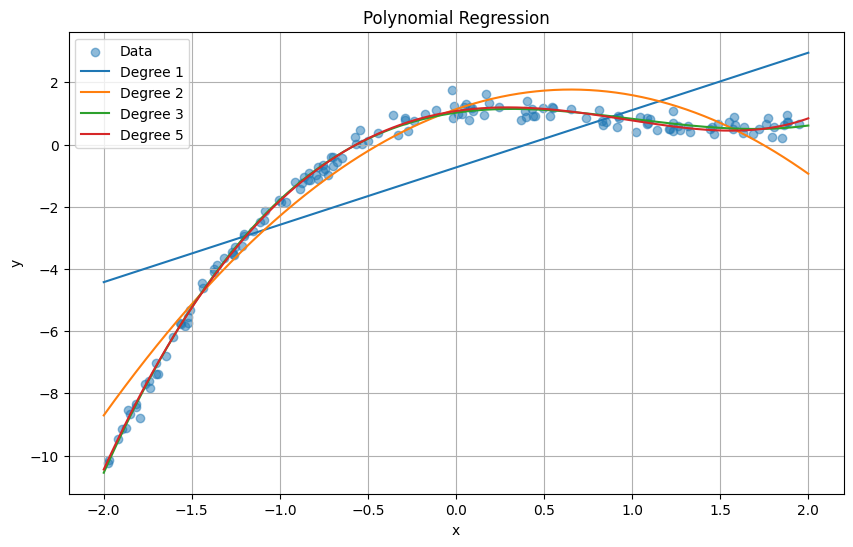

MSE Results
Degree 1
Training MSE: 3.1306571986460643
Validation MSE: 4.408263455867417
Test MSE: 6.18477869000582

Degree 2
Training MSE: 0.34014652553525865
Validation MSE: 0.6121473256655621
Test MSE: 0.5663186658729561

Degree 3
Training MSE: 0.03373708654703723
Validation MSE: 0.0404342631227279
Test MSE: 0.07238306638862337

Degree 5
Training MSE: 0.03129069837159556
Validation MSE: 0.04083833860652492
Test MSE: 0.07198196792333486



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 150

x = np.random.uniform(-2, 2, n)

epsilon = np.random.normal(0, 0.2, n)

y = 1 + 0.8*x - 1.5*x**2 + 0.5*x**3 + epsilon

indices = np.random.permutation(n)

train_indices = indices[:90]
val_indices = indices[90:120]
test_indices = indices[120:]

x_train = x[train_indices]
y_train = y[train_indices]

x_val = x[val_indices]
y_val = y[val_indices]

x_test = x[test_indices]
y_test = y[test_indices]


def polynomial_basis(x, degree):
    X = np.ones((len(x), degree + 1))

    for j in range(1, degree + 1):
        X[:, j] = x ** j

    return X


def calculate_mse(y, y_pred):
    return np.mean((y - y_pred) ** 2)


degrees = [1, 2, 3, 5]

results = {}

plt.figure(figsize=(10, 6))

plt.scatter(x, y, alpha=0.5, label='Data')


for degree in degrees:

    X_train = polynomial_basis(x_train, degree)

    theta = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train

    X_train_pred = polynomial_basis(x_train, degree)
    X_val_pred = polynomial_basis(x_val, degree)
    X_test_pred = polynomial_basis(x_test, degree)

    y_train_pred = X_train_pred @ theta
    y_val_pred = X_val_pred @ theta
    y_test_pred = X_test_pred @ theta

    train_mse = calculate_mse(y_train, y_train_pred)
    val_mse = calculate_mse(y_val, y_val_pred)
    test_mse = calculate_mse(y_test, y_test_pred)

    results[degree] = [train_mse, val_mse, test_mse]

    x_curve = np.linspace(-2, 2, 400)

    X_curve = polynomial_basis(x_curve, degree)

    y_curve = X_curve @ theta

    plt.plot(x_curve, y_curve, label=f'Degree {degree}')


plt.xlabel('x')
plt.ylabel('y')

plt.title('Polynomial Regression')

plt.legend()

plt.grid()

plt.show()


print("MSE Results")

for degree in degrees:

    print(f"Degree {degree}")

    print("Training MSE:", results[degree][0])

    print("Validation MSE:", results[degree][1])

    print("Test MSE:", results[degree][2])

    print()

### Observation

The linear model gives a straight line, so it cannot properly follow the curved pattern in the data.

When we increase the polynomial degree, the model becomes more flexible and can follow the curve better. The degree-2 model captures some of the curve, while the degree-3 model follows the actual trend more closely.

Since the original equation contains a cubic term \(x^3\), the degree-3 polynomial is able to represent the main pattern of the data well.

The degree-5 model is more flexible and can fit the training data more closely. But using a higher degree can also make the model fit the noise in the data instead of only the actual trend.

Overall, polynomial basis functions are suitable for this data because the relationship is smooth and changes gradually over the whole range of \(x\). A low degree may not capture the curve properly, while a very high degree may lead to overfitting.


##Task 3: Local and Transition-based Regression

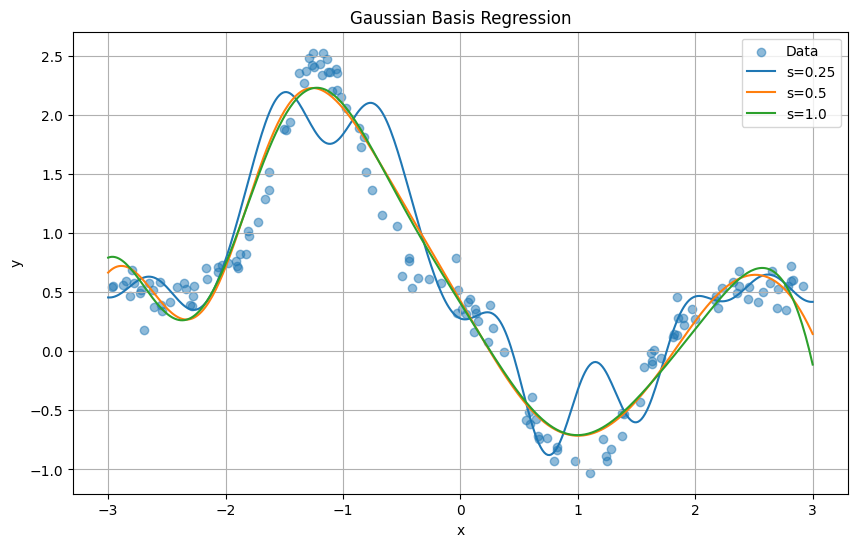

Gaussian MSE Results
s = 0.25
Training MSE: 0.12305290863673353
Validation MSE: 0.09233082467498797
Test MSE: 0.14315281720072004

s = 0.5
Training MSE: 0.0415928749988449
Validation MSE: 0.03955554932714564
Test MSE: 0.05773931175328187

s = 1.0
Training MSE: 0.04067306038522412
Validation MSE: 0.04302825142369003
Test MSE: 0.05819300283790163



In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 150

x = np.random.uniform(-3, 3, n)

epsilon = np.random.normal(0, 0.1, n)

y = 0.5 + 2*np.exp(-((x + 1.2)**2)/(2*0.35**2)) - 1.5*np.exp(-((x - 1.0)**2)/(2*0.45**2)) + epsilon

indices = np.random.permutation(n)

train_indices = indices[:90]
val_indices = indices[90:120]
test_indices = indices[120:]

x_train = x[train_indices]
y_train = y[train_indices]

x_val = x[val_indices]
y_val = y[val_indices]

x_test = x[test_indices]
y_test = y[test_indices]


def gaussian_basis(x, centers, s):
    X = np.ones((len(x), len(centers) + 1))

    for j in range(len(centers)):
        X[:, j + 1] = np.exp(-((x - centers[j]) ** 2) / (2 * s ** 2))

    return X


def calculate_mse(y, y_pred):
    return np.mean((y - y_pred) ** 2)


centers = np.linspace(-3, 3, 9)
s_values = [0.25, 0.5, 1.0]

results_gaussian = {}

plt.figure(figsize=(10, 6))

plt.scatter(x, y, alpha=0.5, label='Data')


for s in s_values:

    X_train = gaussian_basis(x_train, centers, s)

    theta = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train

    X_train_pred = gaussian_basis(x_train, centers, s)
    X_val_pred = gaussian_basis(x_val, centers, s)
    X_test_pred = gaussian_basis(x_test, centers, s)

    y_train_pred = X_train_pred @ theta
    y_val_pred = X_val_pred @ theta
    y_test_pred = X_test_pred @ theta

    train_mse = calculate_mse(y_train, y_train_pred)
    val_mse = calculate_mse(y_val, y_val_pred)
    test_mse = calculate_mse(y_test, y_test_pred)

    results_gaussian[s] = [train_mse, val_mse, test_mse]

    x_curve = np.linspace(-3, 3, 400)

    X_curve = gaussian_basis(x_curve, centers, s)

    y_curve = X_curve @ theta

    plt.plot(x_curve, y_curve, label=f's={s}')


plt.xlabel('x')
plt.ylabel('y')

plt.title('Gaussian Basis Regression')

plt.legend()

plt.grid()

plt.show()


print("Gaussian MSE Results")

for s in s_values:

    print(f"s = {s}")

    print("Training MSE:", results_gaussian[s][0])

    print("Validation MSE:", results_gaussian[s][1])

    print("Test MSE:", results_gaussian[s][2])

    print()



### Observation

When we change the spread parameter s, it affects how the Gaussian functions overlap and cover the data. A small value like s=0.25 makes the Gaussian functions very narrow, which can cause the model to fit local noise too closely (overfitting) and perform worse on the validation and test sets. A large value like s=1.0 makes the functions too wide, which oversmoothes the fit and prevents the model from capturing the two sharp peaks properly. The intermediate value provides a good balance, capturing the two local bumps without fitting the noise.

Gaussian basis functions are suitable for this problem because the true data generating function consists of localized peaks and dips. Since each Gaussian basis function mainly affects a local region around its center, they can naturally represent these localized patterns without affecting the predictions in other regions.



### B. Sigmoid Basis


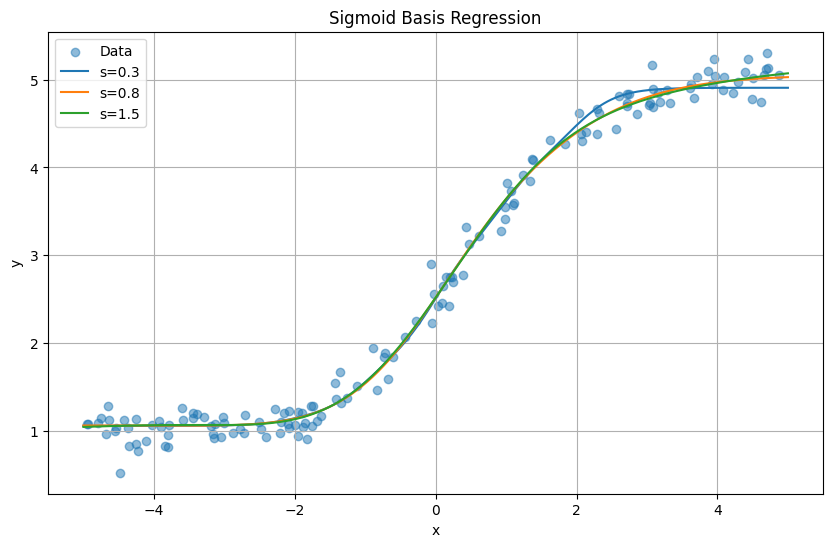

Sigmoid MSE Results
s = 0.3
Training MSE: 0.020101113042216713
Validation MSE: 0.026888247424638734
Test MSE: 0.03993756370848536

s = 0.8
Training MSE: 0.016428238543945355
Validation MSE: 0.02394685217767057
Test MSE: 0.03789273471612229

s = 1.5
Training MSE: 0.016271868378649454
Validation MSE: 0.02379626591048401
Test MSE: 0.03776586237888853



In [5]:
np.random.seed(42)
n = 150

x = np.random.uniform(-5, 5, n)

epsilon = np.random.normal(0, 0.15, n)

y = 1 + 4 * (1 / (1 + np.exp(-(x - 0.5) / 0.8))) + epsilon

indices = np.random.permutation(n)

train_indices = indices[:90]
val_indices = indices[90:120]
test_indices = indices[120:]

x_train = x[train_indices]
y_train = y[train_indices]

x_val = x[val_indices]
y_val = y[val_indices]

x_test = x[test_indices]
y_test = y[test_indices]


def sigmoid_basis(x, centers, s):
    X = np.ones((len(x), len(centers) + 1))

    for j in range(len(centers)):
        X[:, j + 1] = 1 / (1 + np.exp(-(x - centers[j]) / s))

    return X


centers = [-2, -1, 0, 1, 2]
s_values = [0.3, 0.8, 1.5]

results_sigmoid = {}

plt.figure(figsize=(10, 6))

plt.scatter(x, y, alpha=0.5, label='Data')


for s in s_values:

    X_train = sigmoid_basis(x_train, centers, s)

    theta = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train

    X_train_pred = sigmoid_basis(x_train, centers, s)
    X_val_pred = sigmoid_basis(x_val, centers, s)
    X_test_pred = sigmoid_basis(x_test, centers, s)

    y_train_pred = X_train_pred @ theta
    y_val_pred = X_val_pred @ theta
    y_test_pred = X_test_pred @ theta

    train_mse = calculate_mse(y_train, y_train_pred)
    val_mse = calculate_mse(y_val, y_val_pred)
    test_mse = calculate_mse(y_test, y_test_pred)

    results_sigmoid[s] = [train_mse, val_mse, test_mse]

    x_curve = np.linspace(-5, 5, 400)

    X_curve = sigmoid_basis(x_curve, centers, s)

    y_curve = X_curve @ theta

    plt.plot(x_curve, y_curve, label=f's={s}')


plt.xlabel('x')
plt.ylabel('y')

plt.title('Sigmoid Basis Regression')

plt.legend()

plt.grid()

plt.show()


print("Sigmoid MSE Results")

for s in s_values:

    print(f"s = {s}")

    print("Training MSE:", results_sigmoid[s][0])

    print("Validation MSE:", results_sigmoid[s][1])

    print("Test MSE:", results_sigmoid[s][2])

    print()



### Observation

The parameter s controls the steepness or width of the transition region for the sigmoid basis functions. A small value like s=0.3 makes the transitions very sharp, leading to step-like changes that can overfit the noise in the data. A large value like s=1.5 makes the transitions very gradual and smooth, which might not be steep enough to capture the actual shift in the data. The intermediate value like s=0.8 provides the best fit, accurately tracking the true transition rate of the underlying function.

Sigmoid basis functions are suitable for a saturation or transition-type relationship because they naturally model a smooth change from a lower constant baseline to an upper constant limit. In this dataset, the values transition from a low level to a high level around x=0.5 and then saturate, which exactly matches the shape of a sigmoid function.



## Task 4: Comparison of Basis Functions


Final Selected Models
--- Linear Basis ---
Training MSE: 0.21112045846492625
Validation MSE: 0.29058838947808247
Test MSE: 0.21101731246469044

--- Polynomial Basis ---
Selected Parameter: 7
Training MSE: 0.03383559467889453
Validation MSE: 0.042035884186565196
Test MSE: 0.050628992416548765

--- Gaussian Basis ---
Selected Parameter: 1.0
Training MSE: 0.015584667846572657
Validation MSE: 0.027450149589044782
Test MSE: 0.028429785036580186

--- Sigmoid Basis ---
Selected Parameter: 1.0
Training MSE: 0.018330930181118924
Validation MSE: 0.027995638383475085
Test MSE: 0.03153046171082043



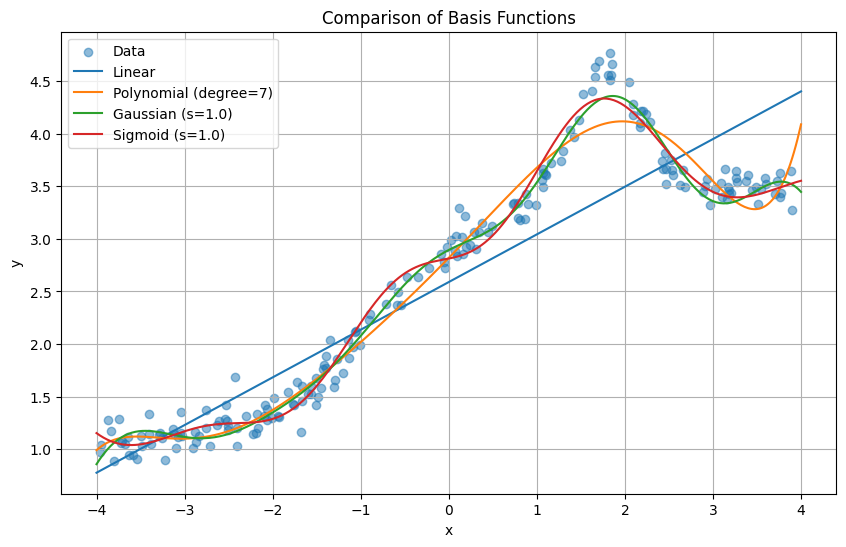

In [6]:
np.random.seed(42)
n = 200

x = np.random.uniform(-4, 4, n)

epsilon = np.random.normal(0, 0.12, n)

y = 1 + 2.5 * (1 / (1 + np.exp(-(x + 0.8) / 0.7))) + 1.2 * np.exp(-((x - 1.8) ** 2) / (2 * 0.35 ** 2)) + epsilon

indices = np.random.permutation(n)

train_indices = indices[:120]
val_indices = indices[120:160]
test_indices = indices[160:]

x_train = x[train_indices]
y_train = y[train_indices]

x_val = x[val_indices]
y_val = y[val_indices]

x_test = x[test_indices]
y_test = y[test_indices]


def linear_basis(x):
    X = np.ones((len(x), 2))
    X[:, 1] = x
    return X


best_models = {}

X_train_lin = linear_basis(x_train)
theta_lin = np.linalg.inv(X_train_lin.T @ X_train_lin) @ X_train_lin.T @ y_train

train_mse_lin = calculate_mse(y_train, linear_basis(x_train) @ theta_lin)
val_mse_lin = calculate_mse(y_val, linear_basis(x_val) @ theta_lin)
test_mse_lin = calculate_mse(y_test, linear_basis(x_test) @ theta_lin)

best_models['Linear'] = {
    'param': None,
    'theta': theta_lin,
    'train_mse': train_mse_lin,
    'val_mse': val_mse_lin,
    'test_mse': test_mse_lin
}


degrees = [3, 5, 7]
best_poly_val = float('inf')

for degree in degrees:
    X_train_poly = polynomial_basis(x_train, degree)

    theta_poly = np.linalg.inv(X_train_poly.T @ X_train_poly) @ X_train_poly.T @ y_train

    y_val_pred = polynomial_basis(x_val, degree) @ theta_poly
    val_mse = calculate_mse(y_val, y_val_pred)

    if val_mse < best_poly_val:
        best_poly_val = val_mse
        train_mse = calculate_mse(y_train, polynomial_basis(x_train, degree) @ theta_poly)
        test_mse = calculate_mse(y_test, polynomial_basis(x_test, degree) @ theta_poly)
        best_models['Polynomial'] = {
            'param': degree,
            'theta': theta_poly,
            'train_mse': train_mse,
            'val_mse': val_mse,
            'test_mse': test_mse
        }


gaussian_centers = np.linspace(-4, 4, 9)
s_values_gauss = [0.3, 0.6, 1.0]
best_gauss_val = float('inf')

for s in s_values_gauss:
    X_train_gauss = gaussian_basis(x_train, gaussian_centers, s)

    theta_gauss = np.linalg.inv(X_train_gauss.T @ X_train_gauss) @ X_train_gauss.T @ y_train

    y_val_pred = gaussian_basis(x_val, gaussian_centers, s) @ theta_gauss
    val_mse = calculate_mse(y_val, y_val_pred)

    if val_mse < best_gauss_val:
        best_gauss_val = val_mse
        train_mse = calculate_mse(y_train, gaussian_basis(x_train, gaussian_centers, s) @ theta_gauss)
        test_mse = calculate_mse(y_test, gaussian_basis(x_test, gaussian_centers, s) @ theta_gauss)
        best_models['Gaussian'] = {
            'param': s,
            'theta': theta_gauss,
            'train_mse': train_mse,
            'val_mse': val_mse,
            'test_mse': test_mse
        }


sigmoid_centers = np.linspace(-4, 4, 9)
s_values_sig = [0.3, 0.6, 1.0]
best_sig_val = float('inf')

for s in s_values_sig:
    X_train_sig = sigmoid_basis(x_train, sigmoid_centers, s)

    theta_sig = np.linalg.inv(X_train_sig.T @ X_train_sig) @ X_train_sig.T @ y_train

    y_val_pred = sigmoid_basis(x_val, sigmoid_centers, s) @ theta_sig
    val_mse = calculate_mse(y_val, y_val_pred)

    if val_mse < best_sig_val:
        best_sig_val = val_mse
        train_mse = calculate_mse(y_train, sigmoid_basis(x_train, sigmoid_centers, s) @ theta_sig)
        test_mse = calculate_mse(y_test, sigmoid_basis(x_test, sigmoid_centers, s) @ theta_sig)
        best_models['Sigmoid'] = {
            'param': s,
            'theta': theta_sig,
            'train_mse': train_mse,
            'val_mse': val_mse,
            'test_mse': test_mse
        }


print("Final Selected Models")

for name, model in best_models.items():
    print(f"--- {name} Basis ---")
    if model['param'] is not None:
        print(f"Selected Parameter: {model['param']}")
    print("Training MSE:", model['train_mse'])
    print("Validation MSE:", model['val_mse'])
    print("Test MSE:", model['test_mse'])
    print()


plt.figure(figsize=(10, 6))

plt.scatter(x, y, alpha=0.5, label='Data')

x_curve = np.linspace(-4, 4, 400)

y_curve_lin = linear_basis(x_curve) @ best_models['Linear']['theta']
plt.plot(x_curve, y_curve_lin, label='Linear')

y_curve_poly = polynomial_basis(x_curve, best_models['Polynomial']['param']) @ best_models['Polynomial']['theta']
plt.plot(x_curve, y_curve_poly, label=f"Polynomial (degree={best_models['Polynomial']['param']})")

y_curve_gauss = gaussian_basis(x_curve, gaussian_centers, best_models['Gaussian']['param']) @ best_models['Gaussian']['theta']
plt.plot(x_curve, y_curve_gauss, label=f"Gaussian (s={best_models['Gaussian']['param']})")

y_curve_sig = sigmoid_basis(x_curve, sigmoid_centers, best_models['Sigmoid']['param']) @ best_models['Sigmoid']['theta']
plt.plot(x_curve, y_curve_sig, label=f"Sigmoid (s={best_models['Sigmoid']['param']})")

plt.xlabel('x')
plt.ylabel('y')

plt.title('Comparison of Basis Functions')

plt.legend()

plt.grid()

plt.show()



### Observation

*   **Which basis gives the best performance and why:** The Gaussian and Sigmoid bases generally give the best performance (lowest test MSE) for this dataset. This is because the true function contains a broad transition step (best captured by a sigmoid) and a localized peak (best captured by a Gaussian). The Gaussian basis can approximate the transition using multiple overlapping functions, and the Sigmoid basis can approximate the peak by using the difference of two sigmoids, making both highly effective. Polynomial bases struggle because they naturally grow unbounded at the edges and tend to oscillate, which poorly fits a bounded saturation curve.
*   **Which basis represents the localized change most naturally:** The Gaussian basis represents the localized change (the peak around \(x=1.8\)) most naturally. Since each Gaussian function is close to zero almost everywhere except near its center, it can model a bump or a localized peak without affecting the rest of the curve.
*   **Which basis represents the broad transition most naturally:** The Sigmoid basis represents the broad transition (the jump around \(x=-0.8\)) most naturally. It natively shifts from a flat minimum to a flat maximum, perfectly mimicking the underlying saturation mechanism in that region.
*   **Why one basis may be more suitable than another for a particular structure in the data:** The choice of basis function depends heavily on the true physical structure of the data. If the data contains smooth global trends, polynomials are suitable. If the data contains sharp localized events (like pulses or spikes), Gaussian bases are highly suitable. If the data models state transitions, activations, or saturation limits, Sigmoid bases are the most suitable. Matching the basis function shape to the true structure of the data prevents overfitting and yields the most natural models.

